In [9]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import gc

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_PATH = '/content/drive/MyDrive/embeddings_assignment/processed_data/'

### PYTORCH DATASET AND CONFIG

In [11]:
class NERDataset(Dataset):
    def __init__(self, data, vocab=None):
        self.sentences = data['tokens']
        self.tags = data['tags']

        if vocab is None:
            self.vocab = {'<PAD>': 0, '<UNK>': 1}
            for sent in self.sentences:
                for token in sent:
                    if token not in self.vocab:
                        self.vocab[token] = len(self.vocab)
        else:
            self.vocab = vocab

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        numerical_inputs = [self.vocab.get(token, self.vocab['<UNK>']) for token in self.sentences[idx]]
        return torch.tensor(numerical_inputs), torch.tensor(self.tags[idx])

In [12]:

def collate_fn(batch):
    sequences, tags = zip(*batch)
    padded_seqs = pad_sequence(sequences, batch_first=True, padding_value=0)
    padded_tags = pad_sequence(tags, batch_first=True, padding_value=-100)
    return padded_seqs, padded_tags

In [13]:
class Word2VecBiLSTM(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, target_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim // 2, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim, target_size)

    def forward(self, x):
        embs = self.embedding(x)
        lstm_out, _ = self.lstm(embs)
        return self.fc(lstm_out)

### 3. EVALUATION ROUTINES

In [14]:

def evaluate_and_plot(train_loss, val_loss, train_acc, val_acc, y_true, y_pred, labels, title):
    epochs = range(1, len(train_loss) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, train_loss, 'b-', label='Train'); ax1.plot(epochs, val_loss, 'r-', label='Val')
    ax1.set_title(f'{title} Loss'); ax1.legend()
    ax2.plot(epochs, train_acc, 'b-', label='Train'); ax2.plot(epochs, val_acc, 'r-', label='Val')
    ax2.set_title(f'{title} Accuracy'); ax2.legend()
    plt.show()
    plt.close('all')

    print(f"\nClassification Report ({title}):")
    print(classification_report(y_true, y_pred, target_names=labels, labels=range(len(labels)), zero_division=0))

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_true, y_pred, labels=range(len(labels))), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f'{title} Confusion Matrix')
    plt.show()
    plt.close('all')



### 4. EXECUTION LOOP

In [18]:
tokenizers = ['whitespace', 'nltk', 'wordpiece']
TAG_LABELS = ['O', 'B-Disease', 'I-Disease']


================ RUNNING: WORD2VEC + WHITESPACE ================
Epoch 1 | Train Loss: 0.1334 Val Loss: 0.1501 | Train Acc: 0.9624 Val Acc: 0.9515
Epoch 2 | Train Loss: 0.0645 Val Loss: 0.1482 | Train Acc: 0.9800 Val Acc: 0.9622
Epoch 3 | Train Loss: 0.0484 Val Loss: 0.1629 | Train Acc: 0.9848 Val Acc: 0.9680
Epoch 4 | Train Loss: 0.0423 Val Loss: 0.1842 | Train Acc: 0.9865 Val Acc: 0.9663
Epoch 5 | Train Loss: 0.0358 Val Loss: 0.1879 | Train Acc: 0.9885 Val Acc: 0.9641
Epoch 6 | Train Loss: 0.0336 Val Loss: 0.1975 | Train Acc: 0.9891 Val Acc: 0.9672
Epoch 7 | Train Loss: 0.0317 Val Loss: 0.1978 | Train Acc: 0.9894 Val Acc: 0.9661
Epoch 8 | Train Loss: 0.0288 Val Loss: 0.2168 | Train Acc: 0.9905 Val Acc: 0.9681
Epoch 9 | Train Loss: 0.0296 Val Loss: 0.1989 | Train Acc: 0.9905 Val Acc: 0.9646
Epoch 10 | Train Loss: 0.0284 Val Loss: 0.1937 | Train Acc: 0.9912 Val Acc: 0.9647


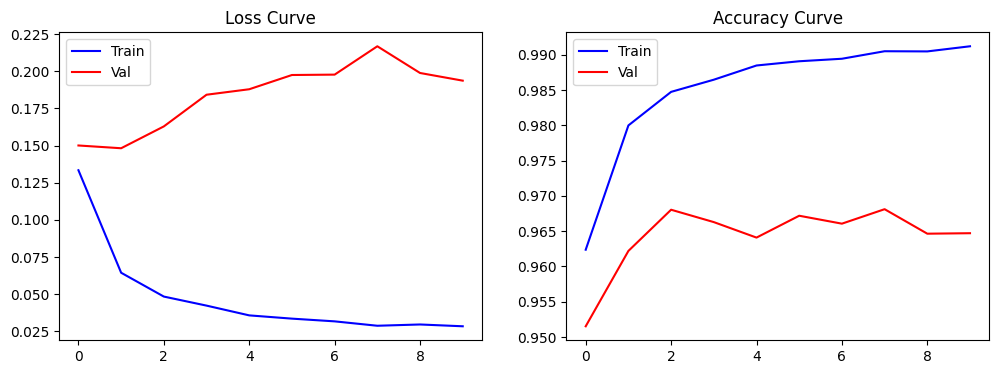

              precision    recall  f1-score   support

           O       0.98      0.98      0.98    117589
   B-Disease       0.68      0.68      0.68      4424
   I-Disease       0.55      0.58      0.57      2737

    accuracy                           0.96    124750
   macro avg       0.74      0.75      0.74    124750
weighted avg       0.96      0.96      0.96    124750



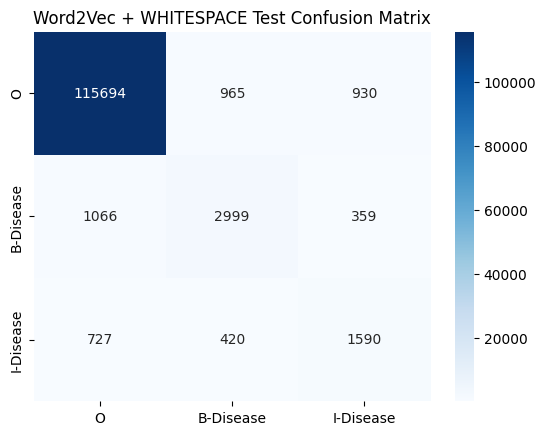


================ RUNNING: WORD2VEC + NLTK ================
Epoch 1 | Train Loss: 0.1355 Val Loss: 0.1265 | Train Acc: 0.9635 Val Acc: 0.9631
Epoch 2 | Train Loss: 0.0635 Val Loss: 0.1343 | Train Acc: 0.9807 Val Acc: 0.9635
Epoch 3 | Train Loss: 0.0490 Val Loss: 0.1707 | Train Acc: 0.9845 Val Acc: 0.9574
Epoch 4 | Train Loss: 0.0413 Val Loss: 0.1636 | Train Acc: 0.9870 Val Acc: 0.9579
Epoch 5 | Train Loss: 0.0371 Val Loss: 0.1855 | Train Acc: 0.9879 Val Acc: 0.9566
Epoch 6 | Train Loss: 0.0335 Val Loss: 0.2173 | Train Acc: 0.9893 Val Acc: 0.9524
Epoch 7 | Train Loss: 0.0309 Val Loss: 0.2437 | Train Acc: 0.9902 Val Acc: 0.9506
Epoch 8 | Train Loss: 0.0294 Val Loss: 0.2068 | Train Acc: 0.9905 Val Acc: 0.9635
Epoch 9 | Train Loss: 0.0281 Val Loss: 0.2365 | Train Acc: 0.9911 Val Acc: 0.9489
Epoch 10 | Train Loss: 0.0274 Val Loss: 0.2353 | Train Acc: 0.9914 Val Acc: 0.9466


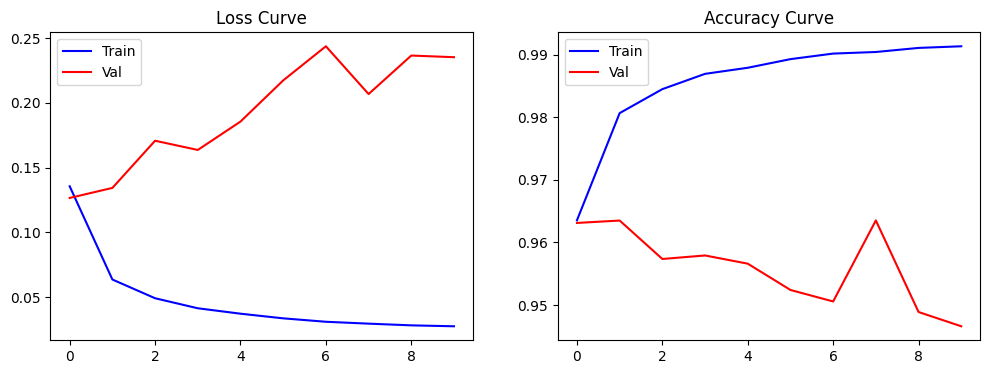

              precision    recall  f1-score   support

           O       0.99      0.96      0.98    117595
   B-Disease       0.55      0.71      0.62      4424
   I-Disease       0.40      0.65      0.49      2737

    accuracy                           0.95    124756
   macro avg       0.65      0.78      0.70    124756
weighted avg       0.96      0.95      0.95    124756



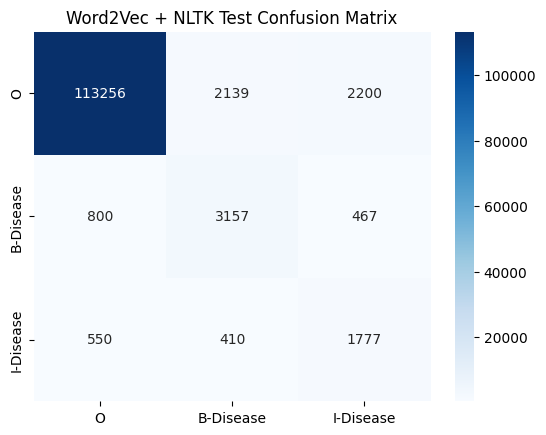


================ RUNNING: WORD2VEC + WORDPIECE ================
Epoch 1 | Train Loss: 0.1323 Val Loss: 0.1297 | Train Acc: 0.9635 Val Acc: 0.9664
Epoch 2 | Train Loss: 0.0748 Val Loss: 0.1386 | Train Acc: 0.9768 Val Acc: 0.9639
Epoch 3 | Train Loss: 0.0637 Val Loss: 0.1368 | Train Acc: 0.9805 Val Acc: 0.9639
Epoch 4 | Train Loss: 0.0540 Val Loss: 0.1551 | Train Acc: 0.9822 Val Acc: 0.9661
Epoch 5 | Train Loss: 0.0535 Val Loss: 0.1612 | Train Acc: 0.9834 Val Acc: 0.9648
Epoch 6 | Train Loss: 0.0493 Val Loss: 0.1686 | Train Acc: 0.9847 Val Acc: 0.9630
Epoch 7 | Train Loss: 0.0466 Val Loss: 0.1666 | Train Acc: 0.9848 Val Acc: 0.9652
Epoch 8 | Train Loss: 0.0452 Val Loss: 0.1698 | Train Acc: 0.9858 Val Acc: 0.9664
Epoch 9 | Train Loss: 0.0420 Val Loss: 0.1770 | Train Acc: 0.9867 Val Acc: 0.9648
Epoch 10 | Train Loss: 0.0419 Val Loss: 0.1857 | Train Acc: 0.9867 Val Acc: 0.9649


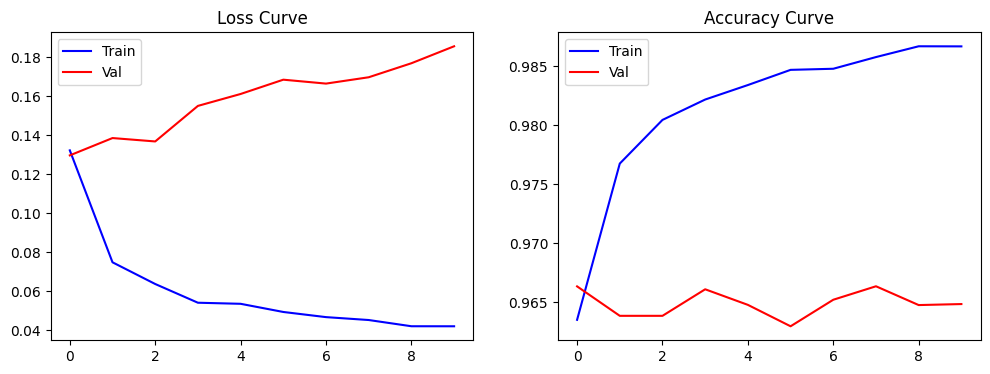

              precision    recall  f1-score   support

           O       0.98      0.99      0.99    117589
   B-Disease       0.70      0.68      0.69      4424
   I-Disease       0.60      0.58      0.59      2737

    accuracy                           0.97    124750
   macro avg       0.76      0.75      0.75    124750
weighted avg       0.97      0.97      0.97    124750



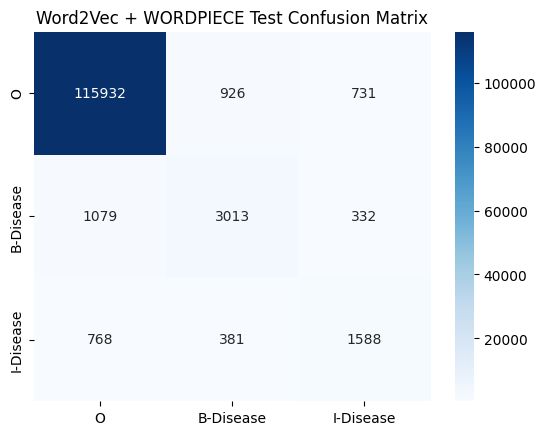

In [19]:
for tok in tokenizers:
    print(f"\n================ RUNNING: WORD2VEC + {tok.upper()} ================")
    with open(f'{BASE_PATH}train_{tok}.pkl', 'rb') as f: train_pkl = pickle.load(f)
    with open(f'{BASE_PATH}val_{tok}.pkl', 'rb') as f: val_pkl = pickle.load(f)
    with open(f'{BASE_PATH}test_{tok}.pkl', 'rb') as f: test_pkl = pickle.load(f)

    train_dataset = NERDataset(train_pkl)
    val_dataset = NERDataset(val_pkl, vocab=train_dataset.vocab)
    test_dataset = NERDataset(test_pkl, vocab=train_dataset.vocab)

    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn)

    model = Word2VecBiLSTM(len(train_dataset.vocab), 300, 128, len(TAG_LABELS)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.CrossEntropyLoss(ignore_index=-100)

    t_loss, v_loss, t_acc, v_acc = [], [], [], []

    # --- TRAINING & VALIDATION PHASE ---
    for epoch in range(10):
        model.train()
        total_train_loss, train_correct, train_total = 0, 0, 0
        for seqs, tags in train_loader:
            seqs, tags = seqs.to(device), tags.to(device)
            optimizer.zero_grad()
            outputs = model(seqs)
            loss = criterion(outputs.view(-1, outputs.shape[-1]), tags.view(-1))
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            preds = torch.argmax(outputs, dim=-1)
            mask = tags != -100
            train_correct += (preds[mask] == tags[mask]).sum().item()
            train_total += mask.sum().item()


        model.eval()
        total_val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for seqs, tags in val_loader:
                seqs, tags = seqs.to(device), tags.to(device)
                outputs = model(seqs)
                loss = criterion(outputs.view(-1, outputs.shape[-1]), tags.view(-1))
                total_val_loss += loss.item()

                preds = torch.argmax(outputs, dim=-1)
                mask = tags != -100
                val_correct += (preds[mask] == tags[mask]).sum().item()
                val_total += mask.sum().item()

        t_loss.append(total_train_loss / len(train_loader))
        t_acc.append(train_correct / max(1, train_total))
        v_loss.append(total_val_loss / len(val_loader))
        v_acc.append(val_correct / max(1, val_total))
        print(f"Epoch {epoch+1} | Train Loss: {t_loss[-1]:.4f} Val Loss: {v_loss[-1]:.4f} | Train Acc: {t_acc[-1]:.4f} Val Acc: {v_acc[-1]:.4f}")

    # Plot curves immediately after training concludes
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(t_loss, 'b-', label='Train'); ax1.plot(v_loss, 'r-', label='Val'); ax1.set_title('Loss Curve'); ax1.legend()
    ax2.plot(t_acc, 'b-', label='Train'); ax2.plot(v_acc, 'r-', label='Val'); ax2.set_title('Accuracy Curve'); ax2.legend()
    plt.show()
    plt.close('all')

    # --- INDEPENDENT POST-TRAINING TEST EVALUATION ---
    model.eval()
    gold_standard, system_predictions = [], []
    with torch.no_grad():
        for seqs, tags in test_loader:
            seqs = seqs.to(device)
            preds = torch.argmax(model(seqs), dim=-1).cpu()
            mask = tags != -100
            gold_standard.extend(tags[mask].tolist())
            system_predictions.extend(preds[mask].tolist())

    print(classification_report(gold_standard, system_predictions, target_names=TAG_LABELS, labels=range(len(TAG_LABELS)), zero_division=0))
    sns.heatmap(confusion_matrix(gold_standard, system_predictions, labels=range(len(TAG_LABELS))), annot=True, fmt='d', cmap='Blues', xticklabels=TAG_LABELS, yticklabels=TAG_LABELS)
    plt.title(f"Word2Vec + {tok.upper()} Test Confusion Matrix")
    plt.show()
    plt.close('all')

    del model, optimizer, train_loader, val_loader, test_loader
    gc.collect()
    torch.cuda.empty_cache()